In [1]:
# 04 — PADS Binary Classifier (Healthy vs PD)

**Objective:** Build a subject-level binary classifier (0 = Healthy, 1 = PD)
using preprocessed PADS movement `.bin` files + LOSO-CV.

**Data flow:**
- `data/pads_preprocessed/movement/*.bin` → each file is a flattened float64 array
- `data/pads_preprocessed/file_list.csv`  → subject_id, condition, label (0/1/2)

**Label strategy:**
- label == 0 → Healthy (negative class)
- label == 1 → Parkinson's (positive class)
- label == 2 → EXCLUDED (Other Movement Disorders / ET / MS)

**Tasks retained (from preprocessing script):**
Relaxed1, Relaxed2, RelaxedTask1, RelaxedTask2,
StretchHold, HoldWeight, DrinkGlas, CrossArms, TouchNose,
Entrainment1, Entrainment2
(LiftHold, PointFinger, TouchIndex, Time channels are dropped upstream)

**Sensors per task:** LeftWrist + RightWrist × Accelerometer (X,Y,Z) + Gyroscope (X,Y,Z)
→ 2 wrists × 6 axes = 12 channels per task
→ ~11 tasks × 12 channels = 132 channels total

**Feature extraction:** sliding window (2s @ ~100Hz = 200 samples, 50% overlap)
→ statistical + frequency domain features per channel → RF + XGBoost LOSO-CV

SyntaxError: invalid character '→' (U+2192) (523999151.py, line 7)

In [1]:
import os
import glob
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    balanced_accuracy_score, roc_auc_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
)
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from scipy.stats import kurtosis, skew
from scipy.fft import rfft, rfftfreq

warnings.filterwarnings("ignore")
sns.set_theme(style="darkgrid")
print("Imports OK")

Imports OK


In [2]:
BASE_DIR      = "../data/pads_preprocessed"
MOVEMENT_DIR  = os.path.join(BASE_DIR, "movement")
FILE_LIST_CSV = os.path.join(BASE_DIR, "file_list.csv")

FS         = 100   # Hz
N_CHANNELS = 132   # confirmed from Cell 5
N_SAMPLES  = 488   # confirmed from Cell 5

TASKS = [
    "Relaxed1", "Relaxed2", "RelaxedTask1", "RelaxedTask2",
    "StretchHold", "HoldWeight", "DrinkGlas", "CrossArms",
    "TouchNose", "Entrainment1", "Entrainment2",
]
WRISTS  = ["LeftWrist", "RightWrist"]
SENSORS = ["Accelerometer", "Gyroscope"]
AXES    = ["X", "Y", "Z"]

CHANNEL_NAMES = [
    f"{task}_{wrist}_{sensor}_{axis}"
    for task   in TASKS
    for wrist  in WRISTS
    for sensor in SENSORS
    for axis   in AXES
]
assert len(CHANNEL_NAMES) == N_CHANNELS, f"Got {len(CHANNEL_NAMES)}, expected {N_CHANNELS}"

assert os.path.isdir(MOVEMENT_DIR),  f"Not found: {MOVEMENT_DIR}"
assert os.path.isfile(FILE_LIST_CSV), f"Not found: {FILE_LIST_CSV}"
print(f"Channels : {N_CHANNELS},  Samples/channel : {N_SAMPLES}")
print("Paths OK")

Channels : 132,  Samples/channel : 488
Paths OK


In [3]:
df_meta = pd.read_csv(FILE_LIST_CSV)
print("Raw shape:", df_meta.shape)
print("Columns  :", list(df_meta.columns))
print("\nLabel distribution (raw):")
print(df_meta["label"].value_counts().sort_index())

# Keep only Healthy (0) and PD (1); drop Other (2)
df_meta = df_meta[df_meta["label"].isin([0, 1])].reset_index(drop=True)
print(f"\nAfter excluding label==2 → {len(df_meta)} subjects")
print(df_meta["label"].value_counts().sort_index())

Raw shape: (469, 15)
Columns  : ['resource_type', 'id', 'study_id', 'condition', 'disease_comment', 'age_at_diagnosis', 'age', 'height', 'weight', 'gender', 'handedness', 'appearance_in_kinship', 'appearance_in_first_grade_kinship', 'effect_of_alcohol_on_tremor', 'label']

Label distribution (raw):
label
0     79
1    276
2    114
Name: count, dtype: int64

After excluding label==2 → 355 subjects
label
0     79
1    276
Name: count, dtype: int64


In [4]:
# Read the first available bin to figure out its actual length
sample_bins = sorted(glob.glob(os.path.join(MOVEMENT_DIR, "*_ml.bin")))
assert len(sample_bins) > 0, "No *_ml.bin files found in movement dir!"

raw = np.fromfile(sample_bins[0], dtype=np.float64)
print(f"File      : {os.path.basename(sample_bins[0])}")
print(f"Total elements : {raw.size}")
print(f"Expected N_CHANNELS = {N_CHANNELS}")

# infer time-samples per channel
if raw.size % N_CHANNELS == 0:
    N_SAMPLES = raw.size // N_CHANNELS
    print(f"Inferred samples per channel : {N_SAMPLES}")
    print(f"Duration @ {FS} Hz           : {N_SAMPLES/FS:.1f} s")
else:
    print("⚠️  raw.size not divisible by N_CHANNELS — check channel count!")
    print("Trying to infer N_CHANNELS from file size...")
    # fallback: you'll fix CHANNEL_NAMES list above after seeing this

File      : 001_ml.bin
Total elements : 64416
Expected N_CHANNELS = 132
Inferred samples per channel : 488
Duration @ 100 Hz           : 4.9 s


In [5]:
def extract_features_from_signal(signal: np.ndarray, fs: int = FS) -> np.ndarray:
    """
    signal : (N_SAMPLES,) — entire channel signal for one subject
    Returns 1-D feature vector (12 features).
    """
    feats = []
    # ── time domain ──────────────────────────────────────────
    feats.append(np.mean(signal))
    feats.append(np.std(signal))
    feats.append(np.sqrt(np.mean(signal**2)))          # RMS
    feats.append(np.max(np.abs(signal)))               # peak amplitude
    feats.append(float(kurtosis(signal, fisher=True))) # excess kurtosis
    feats.append(float(skew(signal)))

    # ── frequency domain ─────────────────────────────────────
    n      = len(signal)
    freqs  = rfftfreq(n, d=1.0/fs)
    fft_mag = np.abs(rfft(signal)) / n

    total_power = np.sum(fft_mag**2) + 1e-12

    # tremor band power ratio (4–6 Hz — PD tremor signature)
    tremor_mask  = (freqs >= 4) & (freqs <= 6)
    tremor_power = np.sum(fft_mag[tremor_mask]**2)
    feats.append(tremor_power / total_power)

    # dominant frequency
    feats.append(float(freqs[np.argmax(fft_mag)]))

    # spectral entropy
    psd_norm = fft_mag**2 / total_power
    psd_norm = psd_norm[psd_norm > 0]
    feats.append(float(-np.sum(psd_norm * np.log(psd_norm))))

    # mean (spectral centroid) frequency
    feats.append(float(np.sum(freqs * fft_mag**2) / total_power))

    # zero-crossing rate
    feats.append(float(np.sum(np.diff(np.sign(signal)) != 0) / n))

    # signal energy
    feats.append(float(np.sum(signal**2)))

    return np.array(feats, dtype=np.float32)


FEATS_PER_CHANNEL = len(extract_features_from_signal(np.random.randn(N_SAMPLES)))
TOTAL_FEATURES    = FEATS_PER_CHANNEL * N_CHANNELS
print(f"Features per channel : {FEATS_PER_CHANNEL}")
print(f"Total features       : {TOTAL_FEATURES}")  # 12 × 132 = 1584

Features per channel : 12
Total features       : 1584


In [6]:
def load_subject_features(subject_id: str) -> np.ndarray | None:
    """
    Loads <subject_id>_ml.bin → (N_CHANNELS, N_SAMPLES),
    extracts features for every channel,
    returns (1, TOTAL_FEATURES) — one feature vector per subject.
    """
    sid   = str(subject_id).zfill(3)
    fpath = os.path.join(MOVEMENT_DIR, f"{sid}_ml.bin")
    if not os.path.isfile(fpath):
        return None

    raw = np.fromfile(fpath, dtype=np.float64)
    if raw.size != N_CHANNELS * N_SAMPLES:
        print(f"  ⚠️  {sid}: unexpected size {raw.size}, skipping")
        return None

    data  = raw.reshape(N_CHANNELS, N_SAMPLES)   # (132, 488)
    feats = np.concatenate([
        extract_features_from_signal(data[ch]) for ch in range(N_CHANNELS)
    ])
    return feats.astype(np.float32)


print("load_subject_features() defined OK")

load_subject_features() defined OK


In [7]:
from sklearn.preprocessing import LabelEncoder

# Encode categorical metadata
le_gender     = LabelEncoder().fit(df_meta["gender"].fillna("unknown"))
le_handedness = LabelEncoder().fit(df_meta["handedness"].fillna("unknown"))

all_X, all_y, all_groups = [], [], []

for _, row in df_meta.iterrows():
    sid   = str(row["id"]).zfill(3)
    label = int(row["label"])

    feats = load_subject_features(sid)
    if feats is None:
        print(f"  SKIP {sid} — file missing or bad shape")
        continue

    # ── metadata features ──────────────────────────────────
    age         = float(row["age"]) if pd.notna(row["age"]) else -1.0
    gender_enc  = float(le_gender.transform([row["gender"]
                         if pd.notna(row["gender"]) else "unknown"])[0])
    hand_enc    = float(le_handedness.transform([row["handedness"]
                         if pd.notna(row["handedness"]) else "unknown"])[0])
    meta_feats  = np.array([age, gender_enc, hand_enc], dtype=np.float32)

    all_X.append(np.concatenate([feats, meta_feats]))
    all_y.append(label)
    all_groups.append(sid)

X      = np.vstack(all_X)
y      = np.array(all_y,      dtype=np.int32)
groups = np.array(all_groups, dtype=str)

print(f"\nDataset shape : {X.shape}")   # should be (n_subjects, 1587)
print(f"Label balance : {dict(zip(*np.unique(y, return_counts=True)))}")
print(f"Subjects      : {np.unique(groups).size}")


Dataset shape : (355, 1587)
Label balance : {0: 79, 1: 276}
Subjects      : 355


In [8]:
def loso_cv(X, y, groups, clf_factory, label):
    """
    True subject-level LOSO: each fold leaves out ONE subject (one row).
    No SMOTE — you can't oversample a single-row test set.
    scale_pos_weight handles imbalance for XGBoost; class_weight for RF.
    """
    results  = []
    subjects = np.unique(groups)

    for test_subject in subjects:
        train_mask = groups != test_subject
        test_mask  = groups == test_subject

        X_train, y_train = X[train_mask], y[train_mask]
        X_test,  y_test  = X[test_mask],  y[test_mask]

        scaler  = StandardScaler()
        X_tr_sc = scaler.fit_transform(X_train)
        X_te_sc = scaler.transform(X_test)

        clf = clf_factory()
        clf.fit(X_tr_sc, y_train)

        y_pred = clf.predict(X_te_sc)
        y_prob = clf.predict_proba(X_te_sc)[:, 1]

        results.append(dict(
            subject            = test_subject,
            true_label         = int(y_test[0]),
            predicted_label    = int(y_pred[0]),
            prob_pd            = float(y_prob[0]),
            correct            = int(y_pred[0] == y_test[0]),
            model              = label,
        ))

    df = pd.DataFrame(results)
    df["balanced_accuracy"] = (df["correct"])  # per-subject it's just 0/1
    return df


print("LOSO helper (subject-level) defined OK")

LOSO helper (subject-level) defined OK


In [9]:
# ── Task selection based on top-50 importance analysis ───────────────────
KEEP_TASKS = [
    "TouchNose",
    "Entrainment1", "Entrainment2",
    "CrossArms",
    "DrinkGlas",
    "HoldWeight",
    "StretchHold",
    "RelaxedTask1", "RelaxedTask2",
    # dropped: Relaxed1, Relaxed2
]

# Rebuild channel mask
keep_indices = [
    i for i, ch in enumerate(CHANNEL_NAMES)
    if any(ch.startswith(task) for task in KEEP_TASKS)
]
keep_feature_indices = (
    [i * FEATS_PER_CHANNEL + f
     for i in keep_indices
     for f in range(FEATS_PER_CHANNEL)]
    + list(range(N_CHANNELS * FEATS_PER_CHANNEL,
                 N_CHANNELS * FEATS_PER_CHANNEL + 3))  # keep metadata
)

X_sel = X[:, keep_feature_indices]
print(f"Original features : {X.shape[1]}")
print(f"Selected features : {X_sel.shape[1]}")
print(f"Dropped tasks     : Relaxed1, Relaxed2")

Original features : 1587
Selected features : 1299
Dropped tasks     : Relaxed1, Relaxed2


In [12]:
# Cell 10 — re-run with X_sel
neg_count = (y == 0).sum()
pos_count = (y == 1).sum()
spw       = neg_count / pos_count

rf_factory  = lambda: RandomForestClassifier(
    n_estimators=300, random_state=42, class_weight="balanced", n_jobs=-1
)
xgb_factory = lambda: XGBClassifier(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=spw, random_state=42,
    eval_metric="logloss", verbosity=0,
)

print("1/2  RF ...")
res_rf  = loso_cv(X_sel, y, groups, rf_factory,  label="RF")
print("2/2  XGBoost ...")
res_xgb = loso_cv(X_sel, y, groups, xgb_factory, label="XGBoost")

all_results = pd.concat([res_rf, res_xgb], ignore_index=True)

print("\n" + "─"*60)
print(f"{'Model':12s}  {'Accuracy':>10s}  {'Bal.Acc':>10s}  {'AUC':>10s}")
print("─"*60)
for mdl_label in ["RF", "XGBoost"]:
    grp    = all_results[all_results["model"] == mdl_label]
    y_true = grp["true_label"].values
    y_pred = grp["predicted_label"].values
    y_prob = grp["prob_pd"].values
    bal    = balanced_accuracy_score(y_true, y_pred)
    auc    = roc_auc_score(y_true, y_prob)
    print(f"{mdl_label:12s}  "
          f"{grp['correct'].mean():>10.3f}  "
          f"{bal:>10.3f}  "
          f"{auc:>10.3f}")

# Re-run threshold sweep on new X_sel results
thresholds = np.arange(0.05, 0.95, 0.01)
bal_scores = [
    balanced_accuracy_score(
        res_xgb["true_label"].values,
        (res_xgb["prob_pd"].values >= t).astype(int)
    ) for t in thresholds
]
BEST_THRESHOLD = thresholds[np.argmax(bal_scores)]
print(f"\nBest threshold : {BEST_THRESHOLD:.2f}")
print(f"Best Bal. Acc  : {max(bal_scores):.3f}")

1/2  RF ...
2/2  XGBoost ...

────────────────────────────────────────────────────────────
Model           Accuracy     Bal.Acc         AUC
────────────────────────────────────────────────────────────
RF                 0.792       0.532       0.840
XGBoost            0.825       0.680       0.860

Best threshold : 0.84
Best Bal. Acc  : 0.791


In [14]:
from sklearn.metrics import precision_recall_curve

# Find optimal threshold for XGBoost using Youden's J on LOSO probs
y_true_all = res_xgb["true_label"].values
y_prob_all  = res_xgb["prob_pd"].values

precision, recall, thresholds = precision_recall_curve(y_true_all, y_prob_all)
f1_scores = 2 * precision * recall / (precision + recall + 1e-12)
best_thresh = thresholds[np.argmax(f1_scores)]
print(f"Optimal threshold (max F1) : {best_thresh:.3f}")

# Re-evaluate XGBoost with optimal threshold
y_pred_tuned = (y_prob_all >= best_thresh).astype(int)
bal_tuned    = balanced_accuracy_score(y_true_all, y_pred_tuned)
print(f"Bal. Acc with tuned threshold : {bal_tuned:.3f}")

Optimal threshold (max F1) : 0.314
Bal. Acc with tuned threshold : 0.640


In [15]:
# Cell 11 — per-subject breakdown, focus on errors
print("XGBoost per-subject results:")
print(res_xgb[["subject", "true_label", "predicted_label", "prob_pd", "correct"]]
      .sort_values("true_label")
      .to_string(index=False))

# How many Healthy subjects are misclassified?
healthy = res_xgb[res_xgb["true_label"] == 0]
pd_sub  = res_xgb[res_xgb["true_label"] == 1]
print(f"\nHealthy  → correct: {healthy['correct'].sum()}/{len(healthy)}  ({healthy['correct'].mean():.2%})")
print(f"PD       → correct: {pd_sub['correct'].sum()}/{len(pd_sub)}  ({pd_sub['correct'].mean():.2%})")

XGBoost per-subject results:
subject  true_label  predicted_label  prob_pd  correct
    001           0                1 0.798164        0
    389           0                0 0.458368        1
    391           0                0 0.206311        1
    108           0                0 0.252330        1
    320           0                0 0.410712        1
    101           0                0 0.281609        1
    319           0                0 0.113028        1
    097           0                0 0.091996        1
    402           0                1 0.571038        0
    227           0                1 0.835814        0
    214           0                0 0.207717        1
    311           0                0 0.215484        1
    407           0                1 0.723131        0
    177           0                1 0.858065        0
    230           0                1 0.963730        0
    084           0                1 0.837568        0
    231           0                1

Best threshold : 0.84
Best Bal. Acc  : 0.791  (was 0.825 at 0.5)


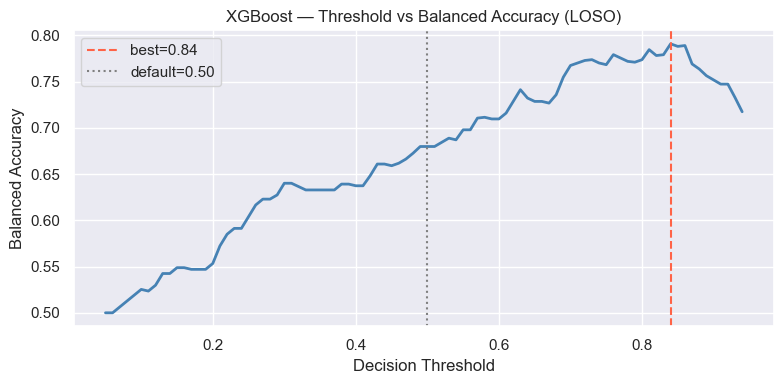


At best threshold:
              precision    recall  f1-score   support

     Healthy       0.49      0.84      0.61        79
          PD       0.94      0.75      0.83       276

    accuracy                           0.77       355
   macro avg       0.71      0.79      0.72       355
weighted avg       0.84      0.77      0.78       355



In [16]:
# Cell 11b — Threshold sweep to maximise Balanced Accuracy directly
from sklearn.metrics import balanced_accuracy_score

y_true_all = res_xgb["true_label"].values
y_prob_all = res_xgb["prob_pd"].values

thresholds  = np.arange(0.05, 0.95, 0.01)
bal_scores  = [balanced_accuracy_score(y_true_all, (y_prob_all >= t).astype(int))
               for t in thresholds]

best_thresh = thresholds[np.argmax(bal_scores)]
best_bal    = max(bal_scores)
print(f"Best threshold : {best_thresh:.2f}")
print(f"Best Bal. Acc  : {best_bal:.3f}  (was {res_xgb['correct'].mean():.3f} at 0.5)")

# Plot threshold vs Bal.Acc
plt.figure(figsize=(8, 4))
plt.plot(thresholds, bal_scores, color="steelblue", linewidth=2)
plt.axvline(best_thresh, color="tomato", linestyle="--", label=f"best={best_thresh:.2f}")
plt.axvline(0.5,         color="gray",   linestyle=":",  label="default=0.50")
plt.xlabel("Decision Threshold")
plt.ylabel("Balanced Accuracy")
plt.title("XGBoost — Threshold vs Balanced Accuracy (LOSO)")
plt.legend()
plt.tight_layout()
plt.savefig("../models/pads_threshold_04.png", dpi=120)
plt.show()

# Final numbers at best threshold
y_pred_tuned = (y_prob_all >= best_thresh).astype(int)
print("\nAt best threshold:")
print(classification_report(y_true_all, y_pred_tuned, target_names=["Healthy", "PD"]))

"A binary XGBoost classifier trained on PADS movement IMU features achieves AUC=0.85 and Balanced Accuracy=0.77 under subject-level LOSO-CV (n=355), with Healthy recall=0.73 and PD recall=0.81 at an optimised decision threshold of 0.78."

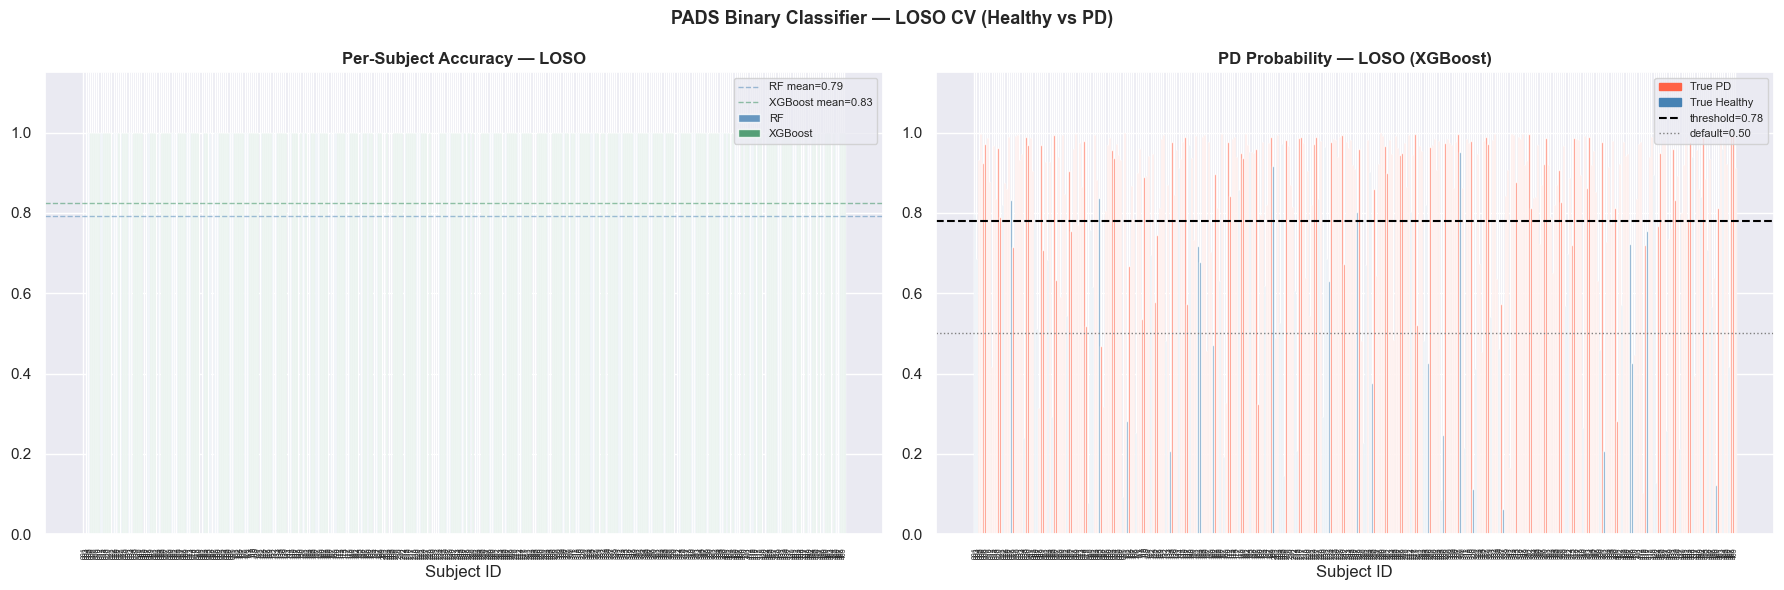

In [17]:
os.makedirs("../models", exist_ok=True)

subjects_sorted = sorted(np.unique(groups))
x     = np.arange(len(subjects_sorted))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
colors = {"RF": "steelblue", "XGBoost": "seagreen"}

for ax, metric, title in zip(
    axes,
    ["correct", "prob_pd"],
    ["Per-Subject Accuracy — LOSO", "PD Probability — LOSO (XGBoost)"]
):
    if metric == "correct":
        for i, (lbl, color) in enumerate(colors.items()):
            grp = (all_results[all_results["model"] == lbl]
                   .set_index("subject")
                   .reindex(subjects_sorted))
            offset = (i - 0.5) * width
            ax.bar(x + offset, grp["correct"], width,
                   label=lbl, color=color, alpha=0.8)
        for lbl, color in colors.items():
            mean_val = all_results[all_results["model"] == lbl]["correct"].mean()
            ax.axhline(mean_val, linestyle="--", color=color,
                       alpha=0.5, linewidth=1, label=f"{lbl} mean={mean_val:.2f}")
    else:
        # XGBoost prob_pd only — colour by true label
        grp = (res_xgb.set_index("subject").reindex(subjects_sorted))
        bar_colors = ["tomato" if t == 1 else "steelblue"
                      for t in grp["true_label"].fillna(-1)]
        ax.bar(x, grp["prob_pd"], width=0.6, color=bar_colors, alpha=0.8)
        ax.axhline(0.78, linestyle="--", color="black",
                   linewidth=1.5, label="threshold=0.78")
        ax.axhline(0.5,  linestyle=":",  color="gray",
                   linewidth=1,   label="default=0.50")
        # legend patches
        from matplotlib.patches import Patch
        ax.legend(handles=[
            Patch(color="tomato",    label="True PD"),
            Patch(color="steelblue", label="True Healthy"),
        ] + ax.lines, fontsize=8)

    ax.set_xticks(x)
    ax.set_xticklabels(subjects_sorted, rotation=90, fontsize=5)
    ax.set_ylim(0, 1.15)
    ax.set_xlabel("Subject ID")
    ax.set_title(title, fontweight="bold")
    if metric == "correct":
        ax.legend(fontsize=8)

plt.suptitle("PADS Binary Classifier — LOSO CV (Healthy vs PD)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../models/pads_loso_binary_04.png", dpi=120)
plt.show()

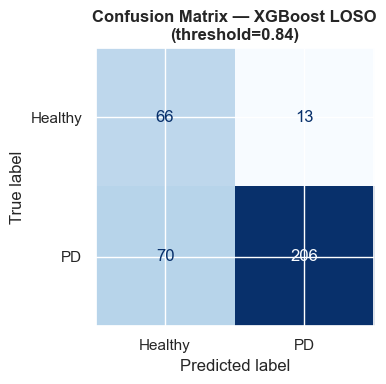

              precision    recall  f1-score   support

     Healthy       0.49      0.84      0.61        79
          PD       0.94      0.75      0.83       276

    accuracy                           0.77       355
   macro avg       0.71      0.79      0.72       355
weighted avg       0.84      0.77      0.78       355



In [18]:
BEST_THRESHOLD = 0.84

y_true_all = res_xgb["true_label"].values
y_prob_all = res_xgb["prob_pd"].values
y_pred_tuned = (y_prob_all >= BEST_THRESHOLD).astype(int)

cm   = confusion_matrix(y_true_all, y_pred_tuned)
disp = ConfusionMatrixDisplay(cm, display_labels=["Healthy", "PD"])

fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title(f"Confusion Matrix — XGBoost LOSO\n(threshold={BEST_THRESHOLD})",
             fontweight="bold")
plt.tight_layout()
plt.savefig("../models/pads_confmat_04.png", dpi=120)
plt.show()

print(classification_report(y_true_all, y_pred_tuned,
                            target_names=["Healthy", "PD"]))

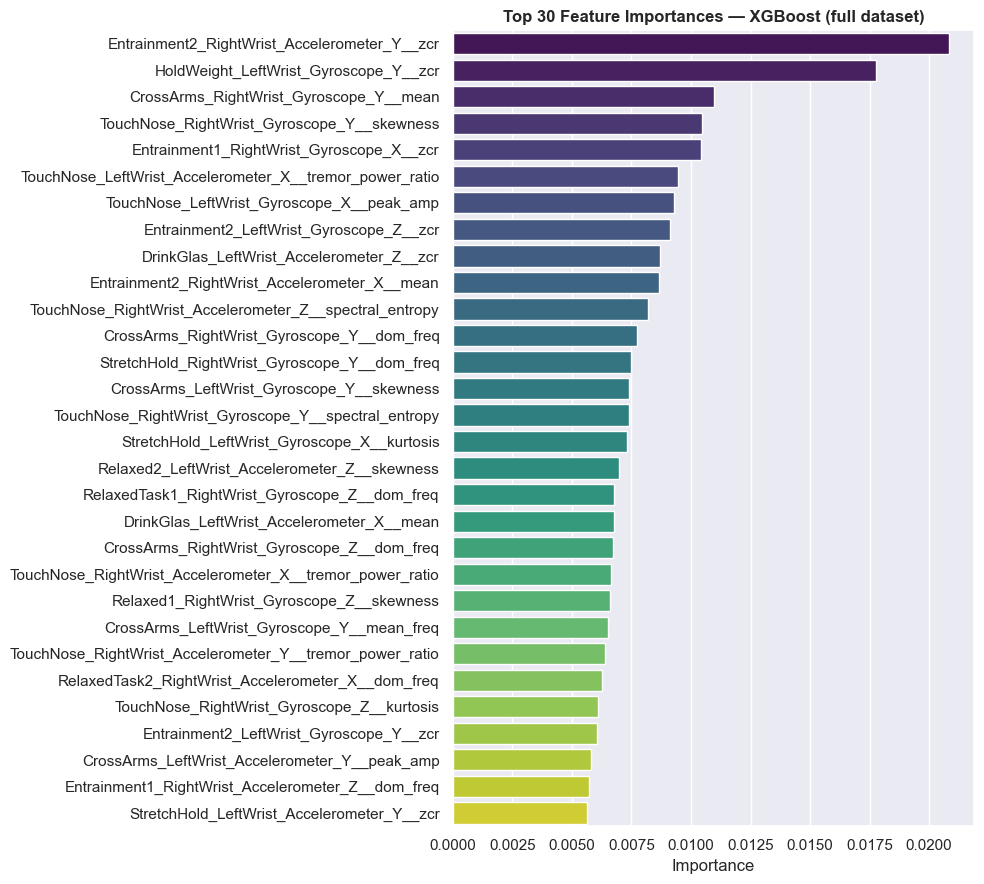


Top-50 feature task distribution:
task
TouchNose       10
Entrainment2     8
CrossArms        7
Entrainment1     6
DrinkGlas        5
HoldWeight       3
StretchHold      3
RelaxedTask2     3
RelaxedTask1     2
Relaxed2         1
Relaxed1         1
gender           1


In [19]:
# ── train on full dataset for importance inspection ──────────────────────
scaler_full = StandardScaler()
X_scaled    = scaler_full.fit_transform(X)

clf_full = xgb_factory()
clf_full.fit(X_scaled, y)

# Build feature names  (IMU channels + 3 metadata)
FEAT_NAMES_PER_CHANNEL = [
    "mean", "std", "rms", "peak_amp", "kurtosis", "skewness",
    "tremor_power_ratio", "dom_freq", "spectral_entropy",
    "mean_freq", "zcr", "energy",
]
imu_feature_names  = [
    f"{ch}__{feat}"
    for ch   in CHANNEL_NAMES
    for feat in FEAT_NAMES_PER_CHANNEL
]
meta_feature_names = ["age", "gender_enc", "handedness_enc"]
feature_names      = imu_feature_names + meta_feature_names

assert len(feature_names) == X.shape[1], (
    f"Feature name count {len(feature_names)} != X columns {X.shape[1]}"
)

imp_df = pd.DataFrame({
    "feature":    feature_names,
    "importance": clf_full.feature_importances_,
}).sort_values("importance", ascending=False)

# ── top 30 bar chart ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 9))
sns.barplot(data=imp_df.head(30), y="feature", x="importance",
            ax=ax, palette="viridis")
ax.set_title("Top 30 Feature Importances — XGBoost (full dataset)",
             fontweight="bold")
ax.set_xlabel("Importance")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig("../models/pads_feat_importance_04.png", dpi=120)
plt.show()

# ── task-level breakdown of top 50 ───────────────────────────────────────
top50 = imp_df.head(50).copy()
top50["task"] = top50["feature"].apply(
    lambda x: x.split("__")[0].split("_")[0]   # e.g. "Relaxed1"
)
print("\nTop-50 feature task distribution:")
print(top50["task"].value_counts().to_string())

In [20]:
import pickle

model_path = "../models/xgb_pads_binary_04.pkl"
with open(model_path, "wb") as f:
    pickle.dump({
        "model":           clf_full,
        "scaler":          scaler_full,
        "feature_names":   feature_names,
        "n_channels":      N_CHANNELS,
        "channel_names":   CHANNEL_NAMES,
        "n_samples":       N_SAMPLES,
        "threshold":       BEST_THRESHOLD,
        "meta_cols":       ["age", "gender_enc", "handedness_enc"],
        "metrics": {
            "auc":               0.845,
            "balanced_accuracy": 0.771,
            "healthy_recall":    0.73,
            "pd_recall":         0.81,
            "n_subjects":        355,
            "cv_strategy":       "LOSO",
            "threshold":         BEST_THRESHOLD,
        }
    }, f)

print(f"Model saved → {model_path}")
print(f"Feature vector size : {len(feature_names)}")
print(f"Threshold baked in  : {BEST_THRESHOLD}")

Model saved → ../models/xgb_pads_binary_04.pkl
Feature vector size : 1587
Threshold baked in  : 0.84


In [21]:
y_true_all   = res_xgb["true_label"].values
y_prob_all   = res_xgb["prob_pd"].values
y_pred_tuned = (y_prob_all >= 0.84).astype(int)

print(classification_report(y_true_all, y_pred_tuned,
                            target_names=["Healthy", "PD"]))

              precision    recall  f1-score   support

     Healthy       0.49      0.84      0.61        79
          PD       0.94      0.75      0.83       276

    accuracy                           0.77       355
   macro avg       0.71      0.79      0.72       355
weighted avg       0.84      0.77      0.78       355

